In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/ComputerVision'
TRAIN_DIR = f'{DATA_DIR}/images/train'
TEST_DIR  = f'{DATA_DIR}/images/test'
LABEL_FILE = f'{DATA_DIR}/genre.xlsx'

True
Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os, glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# Evaluasi
from sklearn.metrics import classification_report, f1_score

print("Setup selesai!")

Setup selesai!


In [ ]:
df = pd.read_excel(LABEL_FILE)
print(df.shape)
print(df.head(5))
print(df.dtypes)

genre_cols = ['action','adventure','animation','comedy','crime',
              'drama','family','fantasy','horror','musical',
              'mystery','romance','scifi','thriller']
print(f"\nTotal genre: {len(genre_cols)}")

(300, 16)
  filename            title  action  adventure  animation  comedy  crime  \
0    1.jpg    Jessica Jones       1          0          0       0      1   
1    2.jpg     Squid Game 2       1          0          0       1      1   
2    3.jpg       Hey Arnold       0          0          1       1      0   
3    4.jpg      Unstopabble       1          0          0       1      1   
4    5.jpg  Superman & Lois       1          1          0       0      0   

   drama  family  fantasy  horror  musical  mystery  romance  scifi  thriller  
0      1       0        0       0        0        0        0      1         1  
1      1       0        0       0        0        0        0      0         1  
2      0       1        0       0        0        0        0      0         0  
3      0       0        0       0        0        0        0      0         1  
4      1       0        0       0        0        0        0      1         0  
filename     object
title        object
action       

Training samples found: 250

Distribusi Genre:
action       167
drama        146
adventure    125
comedy        80
thriller      75
scifi         72
fantasy       71
crime         48
animation     47
mystery       41
romance       38
family        35
horror        22
musical        5
dtype: int64


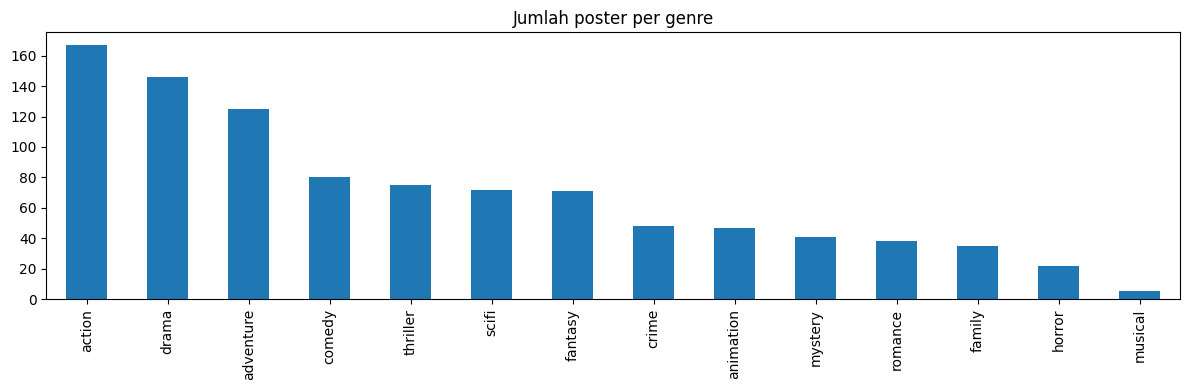

In [ ]:
import os

# Get the list of filenames present in the training directory
train_filenames = set(os.listdir(TRAIN_DIR))

# Filter the dataframe to include only those files
df_train = df[df['filename'].isin(train_filenames)].copy()

print(f"Training samples found: {len(df_train)}")

if len(df_train) > 0:
    genre_counts = df_train[genre_cols].sum().sort_values(ascending=False)
    print("\nDistribusi Genre:")
    print(genre_counts)

    genre_counts.plot(kind='bar', figsize=(12,4), title='Jumlah poster per genre')
    plt.tight_layout()
    plt.savefig('genre_distribution.png')
    plt.show()
else:
    print("Peringatan: Tidak ada file gambar yang cocok ditemukan di TRAIN_DIR.")

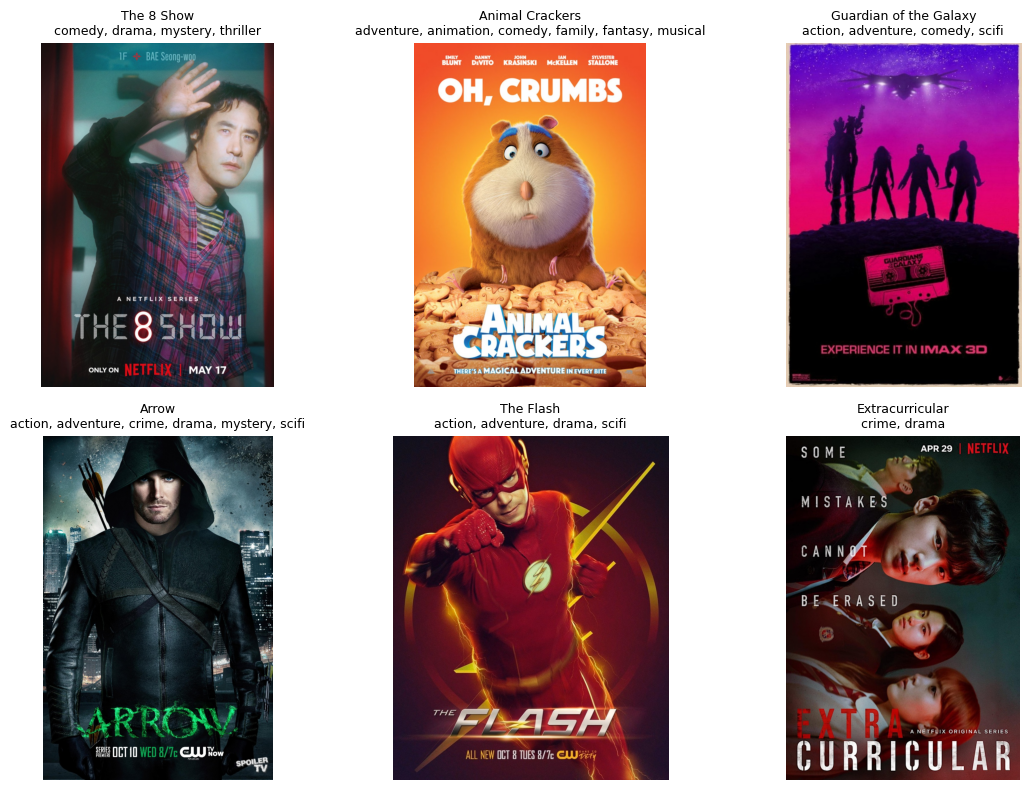

In [ ]:
def show_samples(df, n=6):
    # Ensure we don't try to sample more than what's available
    n = min(n, len(df))
    if n == 0:
        print("No samples available to display.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    # Use a fixed random_state for reproducibility
    for i, (_, row) in enumerate(df.sample(n, random_state=42).iterrows()):
        img_path = os.path.join(TRAIN_DIR, row['filename'])
        img = Image.open(img_path)
        axes[i].imshow(img)

        # Get active genres (value == 1)
        genres = [g for g in genre_cols if row[g] == 1]
        axes[i].set_title(f"{row['title']}\n{', '.join(genres)}", fontsize=9)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(df_train)

In [ ]:
df_train['n_genres'] = df_train[genre_cols].sum(axis=1)
print(df_train['n_genres'].value_counts().sort_index())

print(f"Rata-rata genre per poster: {df_train['n_genres'].mean():.2f}")

n_genres
1     5
2    31
3    60
4    90
5    34
6    19
7     7
8     4
Name: count, dtype: int64
Rata-rata genre per poster: 3.89


In [ ]:
class MoviePosterDataset(Dataset):
    def __init__(self, df, img_dir, genre_cols, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.genre_cols = genre_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row[self.genre_cols].values.astype(float),
            dtype=torch.float32
        )
        return image, label

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3,
        saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    ),
    transforms.RandomErasing(
        p=0.2, scale=(0.02, 0.1))
])



transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

In [ ]:
from sklearn.model_selection import train_test_split

df_tr, df_val = train_test_split(df_train, test_size=0.2,
                                  random_state=42)

train_dataset = MoviePosterDataset(df_tr, TRAIN_DIR,
                                    genre_cols, transform_train)
val_dataset   = MoviePosterDataset(df_val, TRAIN_DIR,
                                    genre_cols, transform_val)

train_loader = DataLoader(train_dataset, batch_size=32,
                           shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32,
                           shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Train: 200 | Val: 50


In [ ]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, 14)
)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model = model.to(device)
print(f"Model siap di: {device}")

Model siap di: cuda


In [ ]:
pos_counts = torch.tensor(
    df_tr[genre_cols].sum().values,
    dtype=torch.float32
)

neg_counts = len(df_tr) - pos_counts
pos_weight = (neg_counts / pos_counts)
pos_weight = torch.clamp(pos_weight, max=10.0)
pos_weight = pos_weight.to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

# Adam + weight_decay
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=25, eta_min=1e-6
)

In [ ]:
def train_model(model, train_loader, val_loader, epochs=30, patience=8):
    best_val_loss = float('inf')
    no_improve = 0
    history = {'train_loss':[],'val_loss':[],'val_f1':[]}
    for epoch in range(epochs):
        # === TRAINING ===
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
             # === VALIDASI ===
        model.eval()
        val_loss, all_preds, all_labels = 0, [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                preds = torch.sigmoid(outputs) > 0.5
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        # Hitung F1 score
        all_preds  = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        f1 = f1_score(all_labels, all_preds, average='samples',
                      zero_division=0)

        train_loss /= len(train_loader)
        val_loss   /= len(val_loader)
        scheduler.step()
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(f1)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train: {train_loss:.4f} | "
              f"Val: {val_loss:.4f} | "
              f"F1: {f1:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve = 0
            torch.save(model.state_dict(),'best_model.pth')
            print(f"  ✓ Model terbaik disimpan!")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stop epoch {epoch+1}")
                break
    return history

history = train_model(model, train_loader, val_loader,
                      epochs=30, patience=8)

Epoch [1/30] Train: 0.9713 | Val: 1.0040 | F1: 0.3506
  ✓ Model terbaik disimpan!
Epoch [2/30] Train: 0.9299 | Val: 0.9886 | F1: 0.3412
  ✓ Model terbaik disimpan!
Epoch [3/30] Train: 0.9202 | Val: 0.9792 | F1: 0.3551
  ✓ Model terbaik disimpan!
Epoch [4/30] Train: 0.8810 | Val: 0.9726 | F1: 0.3854
  ✓ Model terbaik disimpan!
Epoch [5/30] Train: 0.8590 | Val: 0.9672 | F1: 0.4127
  ✓ Model terbaik disimpan!
Epoch [6/30] Train: 0.8505 | Val: 0.9614 | F1: 0.3999
  ✓ Model terbaik disimpan!
Epoch [7/30] Train: 0.8313 | Val: 0.9577 | F1: 0.4141
  ✓ Model terbaik disimpan!
Epoch [8/30] Train: 0.8072 | Val: 0.9521 | F1: 0.4509
  ✓ Model terbaik disimpan!
Epoch [9/30] Train: 0.7745 | Val: 0.9486 | F1: 0.4653
  ✓ Model terbaik disimpan!
Epoch [10/30] Train: 0.7669 | Val: 0.9462 | F1: 0.4633
  ✓ Model terbaik disimpan!
Epoch [11/30] Train: 0.7558 | Val: 0.9461 | F1: 0.4749
  ✓ Model terbaik disimpan!
Epoch [12/30] Train: 0.7328 | Val: 0.9426 | F1: 0.4831
  ✓ Model terbaik disimpan!
Epoch [13/30]

In [ ]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_probs, all_labels_raw = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu()
        all_probs.append(probs)
        all_labels_raw.append(labels)
probs_all  = torch.cat(all_probs).numpy()
labels_all = torch.cat(all_labels_raw).numpy()



best_thresholds = []
print(f"{'Genre':12s}  {'Thr':5s}  {'F1':5s}")
print("-" * 28)
for i, genre in enumerate(genre_cols):
    best_f1, best_thr = 0, 0.5
    for thr in [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
        p = (probs_all[:,i] > thr).astype(int)
        f = f1_score(labels_all[:,i], p,
                     zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, thr
    best_thresholds.append(best_thr)
    print(f"{genre:12s}  {best_thr:.2f}   {best_f1:.3f}")
print(f"\nF1 Macro (optimal thr): ")
preds_opt = np.column_stack([
    (probs_all[:,i] > best_thresholds[i]).astype(int)
    for i in range(14)])
print(f1_score(labels_all, preds_opt,
               average='macro',zero_division=0))

Genre         Thr    F1   
----------------------------
action        0.50   0.865
adventure     0.45   0.643
animation     0.50   0.737
comedy        0.50   0.640
crime         0.50   0.375
drama         0.30   0.810
family        0.45   0.421
fantasy       0.25   0.438
horror        0.25   0.218
musical       0.40   0.400
mystery       0.30   0.456
romance       0.50   0.286
scifi         0.45   0.481
thriller      0.35   0.656

F1 Macro (optimal thr): 
0.5303927834296718


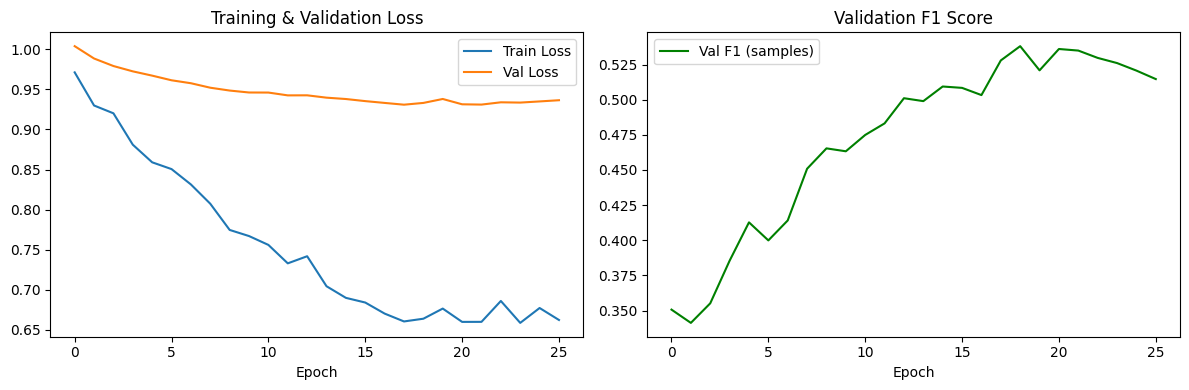

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_title('Training & Validation Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history['val_f1'], color='green', label='Val F1 (samples)')
ax2.set_title('Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [ ]:
# Muat model dengan performa terbaik
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.sigmoid(outputs) > 0.5
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()

# Report per genre
print(classification_report(y_true, y_pred,
      target_names=genre_cols, zero_division=0))

# F1 keseluruhan
print(f"\nF1 Macro  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1 Micro  : {f1_score(y_true, y_pred, average='micro'):.4f}")
print(f"F1 Samples: {f1_score(y_true, y_pred, average='samples'):.4f}")

              precision    recall  f1-score   support

      action       0.78      0.97      0.86        33
   adventure       0.58      0.65      0.61        23
   animation       0.58      1.00      0.74         7
      comedy       0.67      0.62      0.64        13
       crime       0.27      0.60      0.38        10
       drama       0.74      0.62      0.68        32
      family       0.30      0.60      0.40         5
     fantasy       0.33      0.43      0.38        14
      horror       0.20      0.14      0.17         7
     musical       0.00      0.00      0.00         1
     mystery       0.22      0.15      0.18        13
     romance       0.18      0.75      0.29         4
       scifi       0.32      0.77      0.45        13
    thriller       0.50      0.40      0.44        20

   micro avg       0.49      0.62      0.55       195
   macro avg       0.41      0.55      0.44       195
weighted avg       0.53      0.62      0.56       195
 samples avg       0.48   

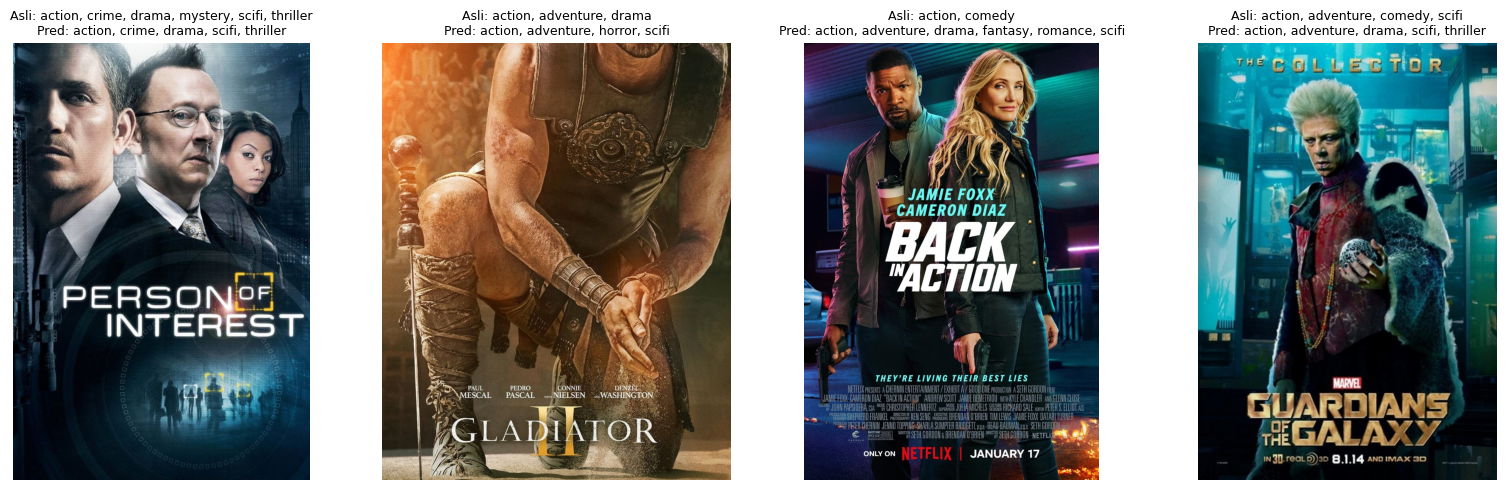

In [ ]:
def visualize_predictions(model, df_val, n=4):
    model.eval()
    samples = df_val.sample(n)
    fig, axes = plt.subplots(1, n, figsize=(16, 5))

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(TRAIN_DIR, row['filename'])
        img = Image.open(img_path).convert('RGB')
        tensor = transform_val(img).unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(tensor)
            pred = torch.sigmoid(out).squeeze().cpu().numpy()

        # Genre asli
        true_genres = [g for g in genre_cols if row[g] == 1]
        # Genre prediksi (threshold 0.5)
        pred_genres = [genre_cols[j] for j,v in enumerate(pred) if v > 0.5]

        axes[i].imshow(img)
        axes[i].set_title(
            f"Asli: {', '.join(true_genres)}\n"
            f"Pred: {', '.join(pred_genres)}", fontsize=9
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig('predictions_sample.png', dpi=150)
    plt.show()

visualize_predictions(model, df_val)

In [ ]:
test_files = sorted(glob.glob(os.path.join(TEST_DIR, '*.jpg')))
print(f"Jumlah gambar test: {len(test_files)}")



results = []
model.eval()
with torch.no_grad():
    for img_path in test_files:
        filename = os.path.basename(img_path)
        img = Image.open(img_path).convert('RGB')
        t = transform_val(img).unsqueeze(0).to(device)
        out = model(t)
        probs = torch.sigmoid(out).squeeze().cpu().numpy()
        preds = [1 if p > thr else 0
                 for p, thr in zip(probs, best_thresholds)]
        row = {'filename': filename}
        row.update(dict(zip(genre_cols, preds)))
        results.append(row)

df_results = pd.DataFrame(results)
df_results.to_excel('predictions.xlsx', index=False)
print("Selesai! predictions.xlsx tersimpan.")

Jumlah gambar test: 50
Selesai! predictions.xlsx tersimpan.


In [ ]:
import shutil

# Simpan model final
torch.save(model.state_dict(),
           f'{DATA_DIR}/final_model.pth')

# Salin hasil prediksi & visualisasi
for f in ['predictions.xlsx', 'training_curves.png',
          'predictions_sample.png', 'genre_distribution.png']:
    shutil.copy(f, f'{DATA_DIR}/{f}')

print("Semua file tersimpan ke Google Drive!")

Semua file tersimpan ke Google Drive!
